### Unit 1 Activity — Gestalt Principles in Data Visualization (UE24CS342AA9)

---

**2:00 PM.** You're a junior analyst at **StreamScope Analytics**. In 40 minutes you're
presenting the content-strategy dashboard to the acquisition team. Your Creative
Director, Meera, left these notes:

> *"Every one of these charts fights against how people naturally group things. Fix each
> one using the Gestalt principle it's missing — I've marked what's broken with a
> `# TODO`."*

Same dataset the team has been using: the Netflix titles catalog.

## ⏱️ Setup — run this first

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("netflix_titles.csv")
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

mission_start = time.time()
print(f"Loaded {len(df):,} rows. 40 minutes on the clock. Go.")
df.head()

Loaded 8,807 rows. 40 minutes on the clock. Go.


  show_id  ... year_added
0      s1  ...     2021.0
1      s2  ...     2021.0
2      s3  ...     2021.0
3      s4  ...     2021.0
4      s5  ...     2021.0

[5 rows x 13 columns]

In [2]:
# Run any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 40 - elapsed_min)
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")

Elapsed: 0.0 min   |   Remaining: 40.0 min


---
## Task 1 — Proximity

Meera's note: *"These rating bars are Movies and TV Shows all in one continuous row --
nobody can tell where one group ends and the other begins. Add a visual gap between the
two groups."*

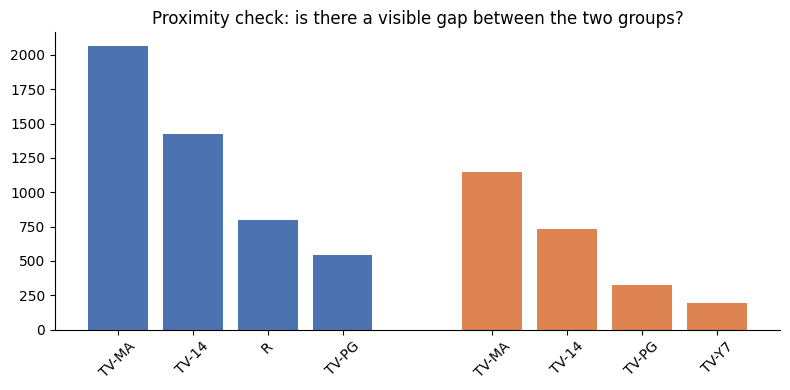

In [3]:
movie_ratings = df[df["type"] == "Movie"]["rating"].value_counts().head(4)
tv_ratings = df[df["type"] == "TV Show"]["rating"].value_counts().head(4)
all_labels = list(movie_ratings.index) + list(tv_ratings.index)
all_values = list(movie_ratings.values) + list(tv_ratings.values)

# TODO 1: build 'positions' so there is a 1-unit GAP between the Movie group and the
# TV Show group (hint: the TV Show positions should start 1 slot later than a
# contiguous range would put them).
positions = list(range(len(movie_ratings))) + [i + len(movie_ratings) + 1 for i in range(len(tv_ratings))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(positions, all_values, color=["#4C72B0"]*len(movie_ratings) + ["#DD8452"]*len(tv_ratings))
ax.set_xticks(positions)
ax.set_xticklabels(all_labels, rotation=45)
ax.set_title("Proximity check: is there a visible gap between the two groups?")
plt.tight_layout()
plt.show()


---
## Task 2 — Similarity

Meera's note: *"Every bar in this grouped chart is a random color right now. Movies
should be one consistent color everywhere, TV Shows another -- so the legend actually
means something."*

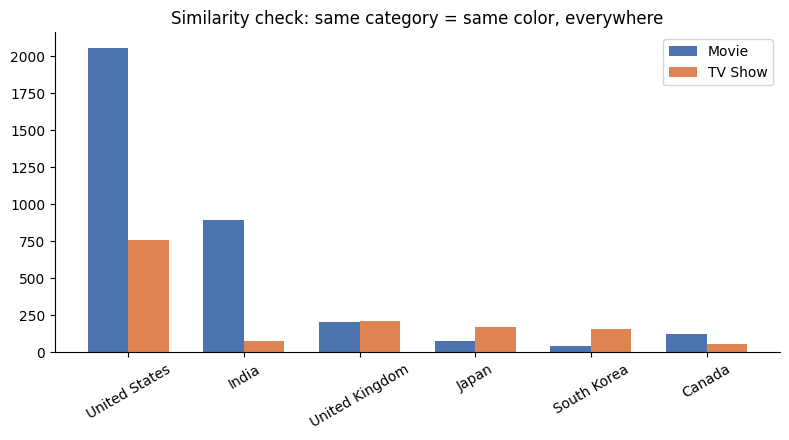

In [4]:
top_countries = df["country"].value_counts().head(6).index
sub = df[df["country"].isin(top_countries)]
grouped = sub.groupby(["country", "type"]).size().unstack(fill_value=0).loc[top_countries]

x = np.arange(len(grouped))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))

# TODO 2: give every "Movie" bar the SAME color, and every "TV Show" bar a different,
# but also consistent, color. Replace the two color values below.
movie_color = "#4C72B0"
tv_color = "#DD8452"

ax.bar(x - width/2, grouped["Movie"], width, label="Movie", color=movie_color)
ax.bar(x + width/2, grouped["TV Show"], width, label="TV Show", color=tv_color)
ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=30)
ax.legend()
ax.set_title("Similarity check: same category = same color, everywhere")
plt.tight_layout()
plt.show()


---
## Task 3 — Connectedness

Meera's note: *"This 2019-vs-2020 comparison is just two separate bar groups -- the
year-over-year *change* is the actual story, and right now it's invisible. Connect each
country's two points with a line."*

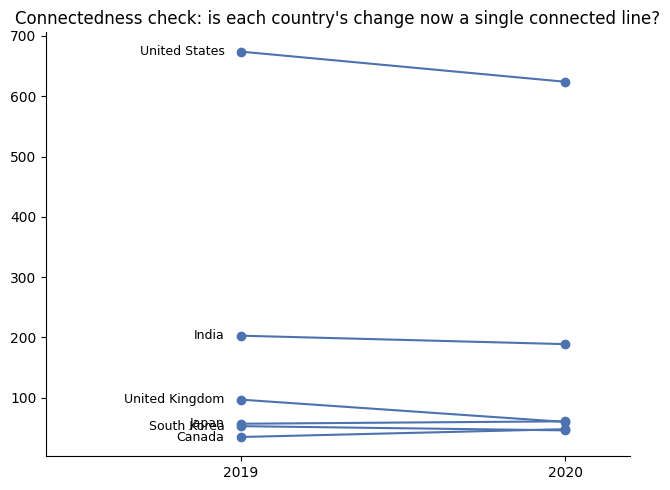

In [5]:
yearly = df[df["year_added"].isin([2019, 2020])]
counts = yearly[yearly["country"].isin(top_countries)].groupby(["country", "year_added"]).size().unstack(fill_value=0)
counts = counts.loc[top_countries]

fig, ax = plt.subplots(figsize=(6.5, 5))
for country in counts.index:
    y2019, y2020 = counts.loc[country, 2019], counts.loc[country, 2020]

    # TODO 3: draw a line connecting (0, y2019) to (1, y2020) using ax.plot,
    # with a marker at each end, so the two points read as ONE connected trend.
    ax.plot([0, 1], [y2019, y2020], marker="o", color="#4C72B0")

    ax.text(-0.05, y2019, country, ha="right", va="center", fontsize=9)

ax.set_xticks([0, 1])
ax.set_xticklabels(["2019", "2020"])
ax.set_xlim(-0.6, 1.2)
ax.set_title("Connectedness check: is each country's change now a single connected line?")
plt.tight_layout()
plt.show()


---
## Task 4 — Continuity

Meera's note: *"This line chart's x-axis is in random order -- the eye can't trace a
path through it. Sort it chronologically."*

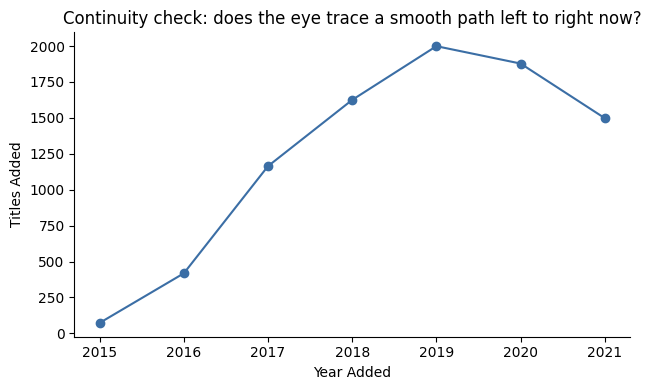

In [6]:
by_year = df["year_added"].value_counts()
by_year = by_year[by_year.index >= 2015]
shuffled = by_year.sample(frac=1, random_state=1)

# TODO 4: create 'ordered' by sorting 'shuffled' (or by_year) into chronological order
ordered = shuffled.sort_index()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(ordered.index, ordered.values, marker="o", color="#3b6ea5")
ax.set_xlabel("Year Added")
ax.set_ylabel("Titles Added")
ax.set_title("Continuity check: does the eye trace a smooth path left to right now?")
plt.tight_layout()
plt.show()


---
## Task 5 — Symmetry

Meera's note: *"Give me a back-to-back bar chart -- Movies on the left, TV Shows on the
right, mirrored around a center line -- so it's easy to compare the two distributions at
a glance."*

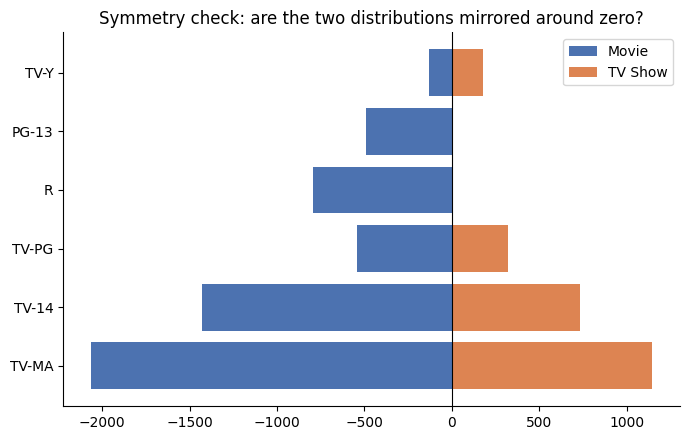

In [7]:
ratings = ["TV-MA", "TV-14", "TV-PG", "R", "PG-13", "TV-Y"]
movie_counts = df[df["type"] == "Movie"]["rating"].value_counts().reindex(ratings, fill_value=0)
tv_counts = df[df["type"] == "TV Show"]["rating"].value_counts().reindex(ratings, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
y = np.arange(len(ratings))

# TODO 5: plot movie_counts going LEFT from zero (negative values) and tv_counts
# going RIGHT from zero (positive values), using ax.barh, to create the mirrored effect.
ax.barh(y, -movie_counts.values, color="#4C72B0", label="Movie")
ax.barh(y, tv_counts.values, color="#DD8452", label="TV Show")

ax.set_yticks(y)
ax.set_yticklabels(ratings)
ax.axvline(0, color="black", lw=0.8)
ax.legend()
ax.set_title("Symmetry check: are the two distributions mirrored around zero?")
plt.tight_layout()
plt.show()


---
## Task 6 — Closure

Meera's note: *"Turn this pie chart into a donut with visible gaps between segments --
it should still read as one complete ring, not five separate pie slices."*

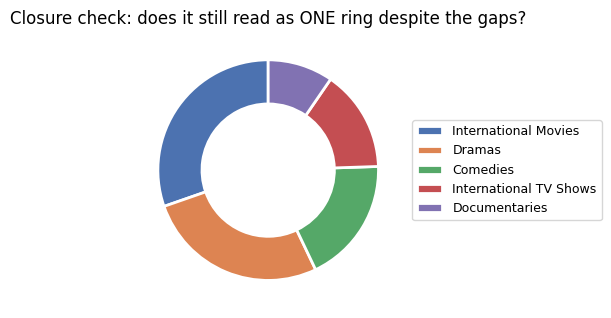

In [8]:
top_genres = df["listed_in"].str.split(", ").explode().value_counts().head(5)

fig, ax = plt.subplots(figsize=(5, 5))

# TODO 6: add a 'wedgeprops' argument to ax.pie that creates a donut hole (width) AND
# a visible white gap between segments (edgecolor + linewidth).
wedges, _ = ax.pie(top_genres.values,
                    colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"],
                    startangle=90,
                    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2})

ax.legend(wedges, top_genres.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_title("Closure check: does it still read as ONE ring despite the gaps?")
plt.tight_layout()
plt.show()


---
## Task 7 — Common Region

Meera's note: *"These three summary numbers are just floating text right now -- put a
card/border around each one so they read as distinct, self-contained metrics."*

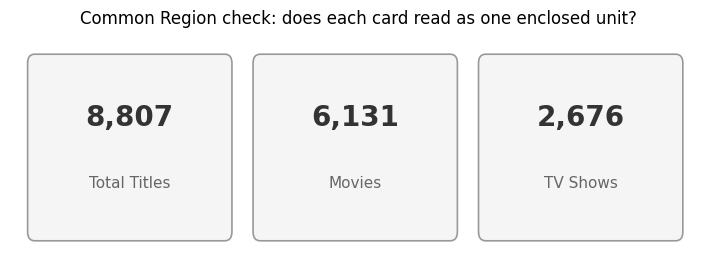

In [9]:
metrics = [
    ("Total Titles", f"{len(df):,}"),
    ("Movies", f"{(df['type']=='Movie').sum():,}"),
    ("TV Shows", f"{(df['type']=='TV Show').sum():,}"),
]

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")

for i, (label, value) in enumerate(metrics):
    x0 = i * 3.2

    # TODO 7: add a FancyBboxPatch (or Rectangle) around this card's text so the number
    # and its label are visually enclosed together -- see the demo notebook for the pattern.
    card = patches.FancyBboxPatch((x0, 0), 2.8, 2,
                                   boxstyle="round,pad=0.05,rounding_size=0.1",
                                   linewidth=1.2, edgecolor="#999999", facecolor="#f5f5f5")
    ax.add_patch(card)

    ax.text(x0 + 1.4, 1.25, value, ha="center", fontsize=20, fontweight="bold", color="#333333")
    ax.text(x0 + 1.4, 0.55, label, ha="center", fontsize=11, color="#666666")

ax.set_xlim(-0.3, 3 * 3.2)
ax.set_ylim(-0.3, 2.3)
ax.set_title("Common Region check: does each card read as one enclosed unit?")
plt.show()


---
## Task 8 — Figure & Ground

Meera's note: *"This chart's bars are barely darker than the background -- fix the
contrast so the bars are unmistakably the 'figure.'"*

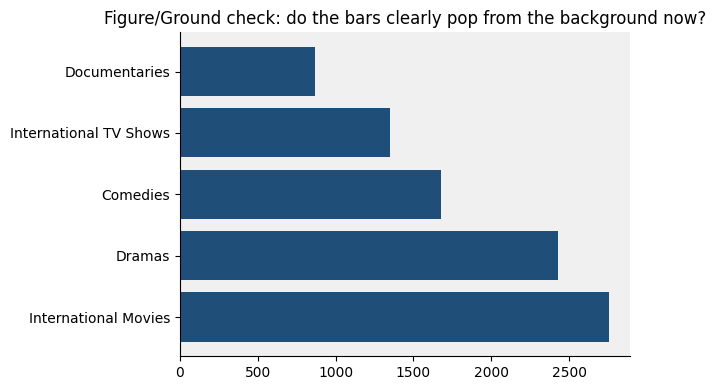

In [10]:
top5 = df["listed_in"].str.split(", ").explode().value_counts().head(5)

fig, ax = plt.subplots(figsize=(6.5, 4))

# TODO 8: pick a background color and a bar color with strong contrast between them
# (currently they're almost identical grays).
ax.set_facecolor("#f0f0f0")
ax.barh(top5.index, top5.values, color="#1f4e79")

ax.set_title("Figure/Ground check: do the bars clearly pop from the background now?")
plt.tight_layout()
plt.show()


---
## Task 9 — Common Fate

Meera's note: *"In this small-multiples trend chart, highlight only the country whose
titles are RISING the fastest -- every other line should fade into gray so the rising
one visually 'groups' with the word 'growth.'"*

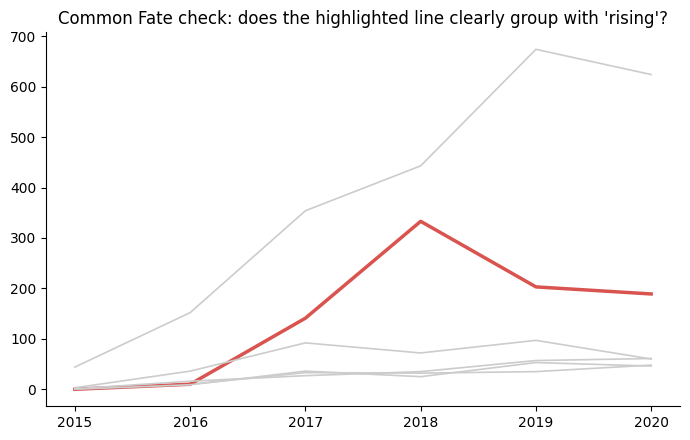

In [11]:
by_year_country = df[df["country"].isin(top_countries)].groupby(["year_added", "country"]).size().unstack(fill_value=0)
by_year_country = by_year_country.loc[(by_year_country.index >= 2015) & (by_year_country.index <= 2020)]

# TODO 9: find the country name (a string) whose value at the LAST year in
# by_year_country is highest relative to its FIRST year (i.e. the biggest riser).
growth = by_year_country.iloc[-1] / by_year_country.iloc[0]
fastest_riser = growth.idxmax()

fig, ax = plt.subplots(figsize=(7, 4.5))
for country in by_year_country.columns:
    color = "#D9534F" if country == fastest_riser else "#cccccc"
    lw = 2.5 if country == fastest_riser else 1.2
    ax.plot(by_year_country.index, by_year_country[country], color=color, lw=lw)

ax.set_title("Common Fate check: does the highlighted line clearly group with 'rising'?")
plt.tight_layout()
plt.show()


---
## Reflection

Answer briefly in this markdown cell:

1. Which one of the nine Gestalt fixes above would you argue matters *most* for a
   dashboard viewed for only a few seconds, and why?
2. Pick two principles that worked together in the same chart (e.g. Task 1's proximity
   + Task 2's similarity) — how did they reinforce each other?
3. In one sentence, restate the chapter's core idea: Gestalt principles let a chart's
   *__________* do the organizing work instead of the *__________*.

**Your answers:**

1. I feel that **proximity from Task 1** matters the most when someone looks at a dashboard for only a few seconds. The spacing immediately shows that Movies and TV Shows are separate groups, even before the viewer reads the labels.
2. **Proximity and similarity** worked well together in the comparison. The gap separated Movies from TV Shows, while the repeated colors helped me identify the same categories throughout the chart. Because both spacing and color showed the same grouping, the chart was quicker and easier to understand.
3. Gestalt principles let a chart's **visual structure** do the organizing work instead of the **viewer's conscious effort**.
